<a href="https://colab.research.google.com/github/mobadara/precision-diagnostics-xai/blob/main/notebooks/00_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploratory Data Analysis (EDA): Chest X-Ray Dataset**

**Objective:** Analyze the Kaggle Chest X-Ray dataset to understand class distribution, visualize sample X-rays, and determine the variance in image dimensions before establishing our PyTorch preprocessing pipeline.

## **Library Imports and Path Setup**
We will use `matplotlib` and `seaborn` for visualization, and `PIL` (Pillow) to inspect the raw image headers without loading the entire dataset into memory.

In [6]:
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np

# Define the base paths based on our automated download script
base_dir = '../dataset/chest_xray'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

CLASSES: list = ['NORMAL', 'PNEUMONIA']

print("Paths configured successfully.")

Paths configured successfully.


## **Class Distribution Analysis**
Medical datasets frequently suffer from severe class imbalance. We need to count exactly how many images exist in each class across our training, validation, and testing sets to determine if we need to apply class weights during model training.

In [7]:
def count_images(directory: str) -> dict[str, int]:
    """
    Counts the number of images in each class within a specified directory.

    Args:
        directory (str): The path to the directory containing class subdirectories.

    Returns:
        dict[str, int]: A dictionary where keys are class names and values are the
                        count of images in each class.
    """
    counts = {}
    for cls in CLASSES:
        path = os.path.join(directory, cls, '*')
        counts[cls] = len(glob.glob(path))
    return counts

Training Set: Normal=1341, Pneumonia=3875
Validation Set: Normal=8, Pneumonia=8
Testing Set: Normal=234, Pneumonia=390


/tmp/ipykernel_24833/1535499192.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), palette=['#2ECC71', '#E74C3C'])


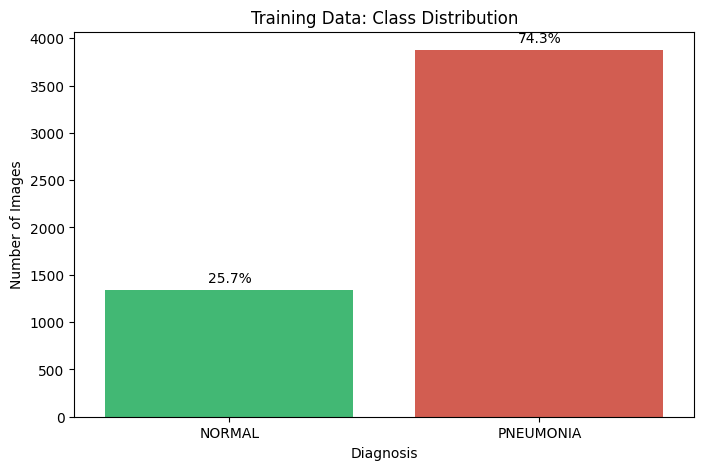

In [9]:
train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)

# Print the exact numbers
print(f"Training Set: Normal={train_counts['NORMAL']}, Pneumonia={train_counts['PNEUMONIA']}")
print(f"Validation Set: Normal={val_counts['NORMAL']}, Pneumonia={val_counts['PNEUMONIA']}")
print(f"Testing Set: Normal={test_counts['NORMAL']}, Pneumonia={test_counts['PNEUMONIA']}")

# Visualize the training distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), palette=['#2ECC71', '#E74C3C'])
plt.title('Training Data: Class Distribution')
plt.ylabel('Number of Images')
plt.xlabel('Diagnosis')

# Add percentages on top of the bars
total_train_images = sum(train_counts.values())
for i, (cls, count) in enumerate(train_counts.items()):
    percentage = (count / total_train_images) * 100
    plt.text(i, count + 50, f'{percentage:.1f}%', ha='center', va='bottom') # Adjust offset (50) as needed

plt.show()

## **Visual Inspection of Pathology**
We need to visually inspect what the model will actually "see". Bacterial and viral pneumonia typically present as cloudy, opaque areas (infiltrates) in the lungs compared to the clear, dark spaces of normal lungs.

In [11]:
import random

def plot_random_samples(num_samples: int = 3) -> None:
    """
    Plots random sample images for each class from the training directory.

    Args:
        num_samples (int): The number of random samples to plot for each class.

    Returns:
        None               Defaults to 3.
    """
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 8))

    for i, cls in enumerate(CLASSES):
        # Get all image paths for the class
        img_paths = glob.glob(os.path.join(train_dir, cls, '*'))
        # Select random samples
        random_paths = random.sample(img_paths, num_samples)

        for j, path in enumerate(random_paths):
            img = Image.open(path)
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].set_title(f'{cls} \n Size: {img.size}')
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

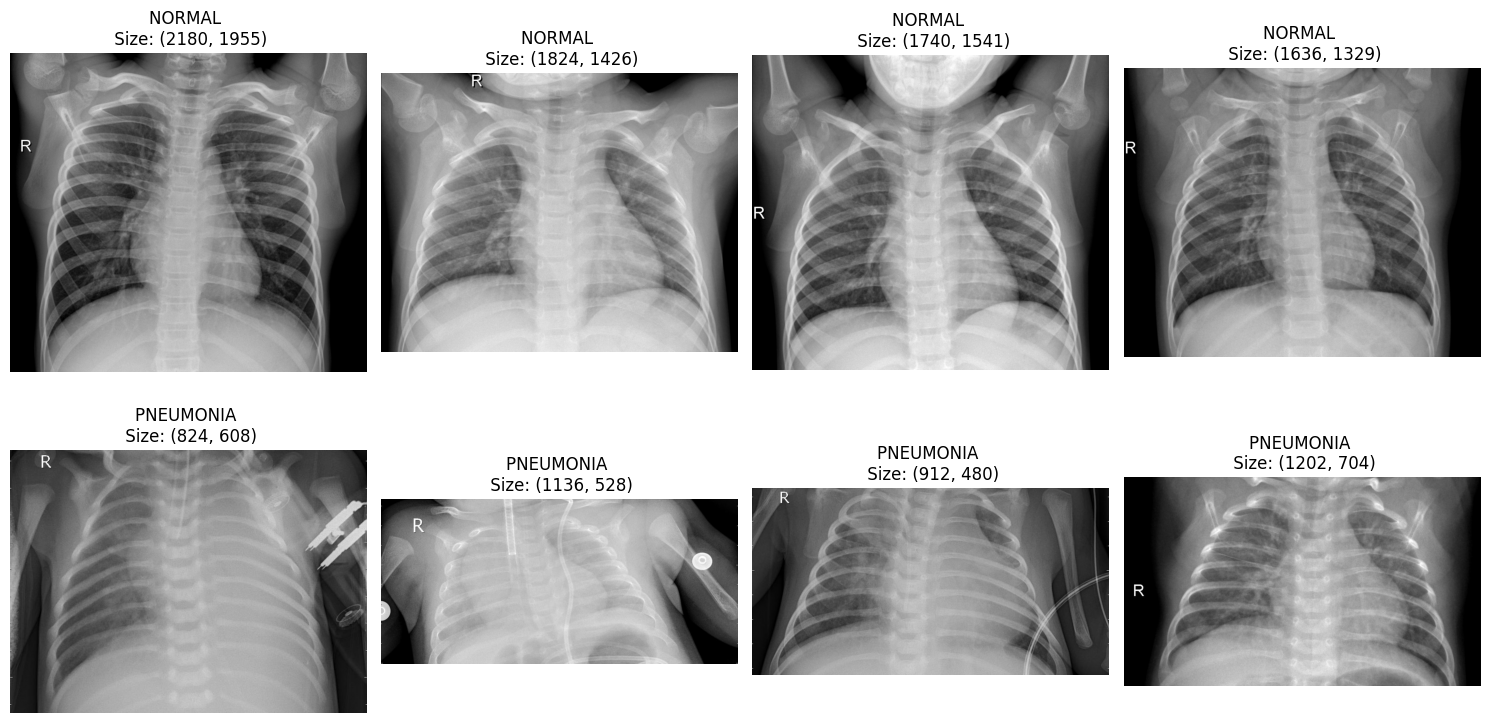

In [12]:
plot_random_samples(num_samples=4)

## **Image Resolution Variance**
Unlike standard datasets (like MNIST or CIFAR-10), medical scans come from different machines and hospitals. We must plot the distribution of image widths and heights to choose a sensible target resolution for our PyTorch `Resize` transforms.

In [15]:
def analyze_dimensions(sample_size: int = 500) -> None:
    """
    Analyzes and visualizes the distribution of image dimensions from a sample of the training set.

    Args:
        sample_size (int): The number of images to sample for dimension analysis. Defaults to 500.

    Returns:
        None
    """
    widths = []
    heights = []

    # Randomly sample images across both classes to save memory/time
    all_images = glob.glob(os.path.join(train_dir, '*/*'))
    sample_paths = random.sample(all_images, min(sample_size, len(all_images)))

    for path in sample_paths:
        with Image.open(path) as img:
            widths.append(img.size[0])
            heights.append(img.size[1])

    # Plotting the joint distribution
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=widths, y=heights, alpha=0.5, color='navy')
    plt.title('Distribution of Image Dimensions (Sample)')
    plt.xlabel('Image Width (pixels)')
    plt.ylabel('Image Height (pixels)')

    # Adding a red dot for our planned DenseNet target resolution
    plt.scatter(224, 224, color='red', marker='X', s=200, label='Target Resolution (224x224)')
    plt.legend()
    plt.show()

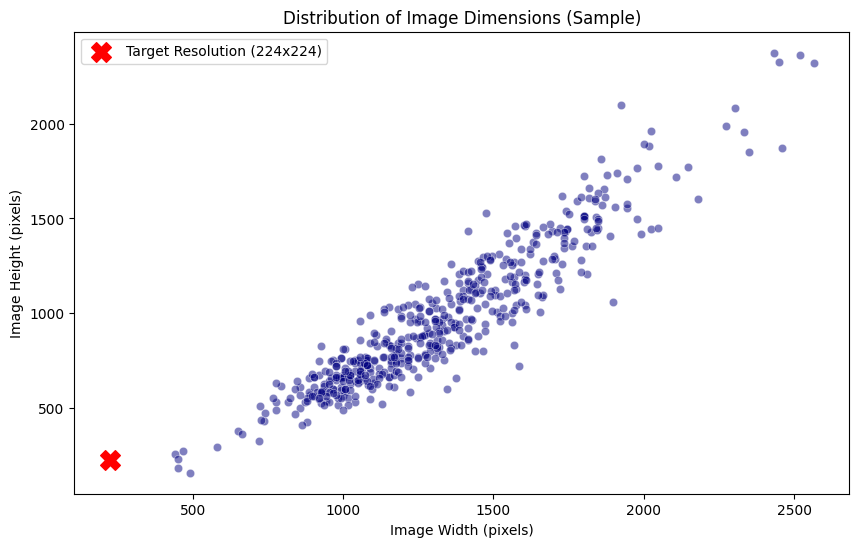

In [16]:
analyze_dimensions()

### **EDA Conclusion and Preprocessing Strategy**

Our exploratory data analysis has revealed two critical characteristics of the Kaggle Chest X-Ray dataset. To ensure our DenseNet121 model learns effectively and does not overfit, we will implement the following strategies in our training pipeline.

### 1. Handling Image Resolution Variance
* **The Problem:** Raw X-rays vary wildly in size, typically ranging from 1000x1000 to over 2500x2500 pixels. Neural networks require standardized input dimensions to process batches on the GPU.
* **The Action:** We will apply PyTorch's `transforms.Resize((224, 224))` to all images during the data loading phase.
* **The Justification:** The DenseNet121 architecture was explicitly designed and pre-trained on 224x224 images. While aggressive downsampling removes some pixel-level detail, DenseNet's densely connected layers are highly efficient at preserving critical spatial hierarchies and high-level pathological features (like lung opacities) even at lower resolutions.

### 2. Mitigating Class Imbalance
* **The Problem:** The training set is highly skewed, containing roughly three times as many "Pneumonia" scans (74.3%) as "Normal" scans (25.7%). If left unaddressed, the model could achieve a high baseline accuracy simply by predicting "Pneumonia" every time, failing to learn the features of a healthy lung.
* **The Action:** We will dynamically calculate inverse class frequencies and pass them as **Class Weights** directly into the PyTorch `CrossEntropyLoss` function.
* **The Justification:** Using class weights is significantly safer in medical imaging than oversampling (duplicating) the minority class. Heavy data augmentation to balance the counts runs the risk of forcing the model to learn the artificial artifacts of the augmentation itself. By weighting the loss function instead, we mathematically penalize the model more heavily when it misclassifies a "Normal" lung, forcing it to pay equal attention to both classes.

### 3. Preventing General Overfitting
* **The Action:** We will apply light data augmentation—specifically `RandomRotation(10)` and `ColorJitter`—exclusively to the training set.
* **The Justification:** Medical scans have incredibly low structural variance (the subject is always a human chest). Light rotations simulate real-world patient misalignment, while color jitter accounts for varying exposure settings across different X-ray machines. This ensures the model learns robust pathological features rather than memorizing the exact pixel layouts of the training set.

---
**Next Phase:** With the data profiled and the preprocessing strategy defined, we will move to the core training notebook to ingest the images, configure these transforms, and begin fine-tuning the DenseNet121 architecture.

___
Muyiwa J. Obadara